# Bar Charts

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [33]:
df_comp = df[['ConvertedCompYearly']].dropna()

(array([1.8946e+04, 3.8410e+03, 3.9600e+02, 1.2700e+02, 2.8000e+01,
        3.4000e+01, 1.1000e+01, 1.1000e+01, 4.0000e+00, 9.0000e+00,
        6.0000e+00, 3.0000e+00, 2.0000e+00, 2.0000e+00, 1.0000e+00,
        3.0000e+00, 2.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.00

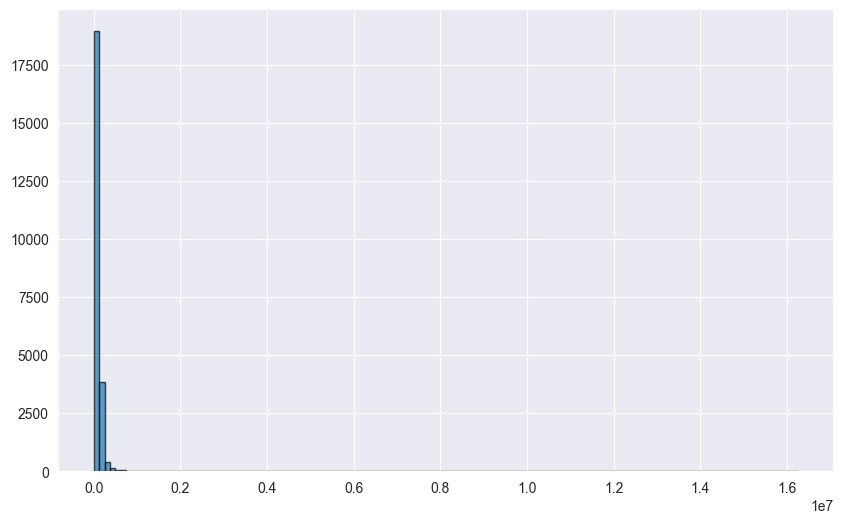

In [34]:
plt.figure(figsize=(10,6))
plt.hist(df_comp['ConvertedCompYearly'], bins=130, edgecolor='black', alpha=0.7)

<Axes: xlabel='ConvertedCompYearly', ylabel='Count'>

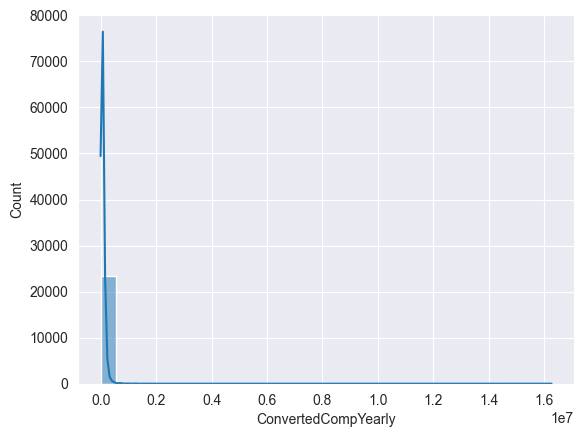

In [35]:
sns.histplot(df_comp['ConvertedCompYearly'], bins=30, kde=True)

In [36]:
df['Age'].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [37]:
import re
import numpy as np


def convert_age(column: str) -> int:
    if isinstance(column, str):
        if 'older' in column:
            match = re.search(r'\d+', column)
            if match:
                return float(match.group()) + 1
        elif 'Under' in column:
            match = re.search(r'\d+', column)
            if match:
                return float(match.group()) - 1
        elif 'Prefer not' in column:
            return np.nan
        else:
            match = re.findall(r'\d+', column)
            if match:
                return sum(float(i) for i in match) / len(match)

In [38]:
age_category = df['Age'].value_counts()

In [42]:
age_map = {}
for age in age_category.index:
    age_map[age] = convert_age(age)

In [43]:
age_map

{'25-34 years old': 29.5,
 '35-44 years old': 39.5,
 '18-24 years old': 21.0,
 '45-54 years old': 49.5,
 '55-64 years old': 59.5,
 'Under 18 years old': 17.0,
 '65 years or older': 66.0,
 'Prefer not to say': nan}

In [44]:
df['AgeNumeric'] = df['Age'].map(age_map)

In [45]:
df['AgeNumeric']

0        17.0
1        39.5
2        49.5
3        21.0
4        21.0
         ... 
65432    21.0
65433    29.5
65434    29.5
65435    21.0
65436    21.0
Name: AgeNumeric, Length: 65437, dtype: float64

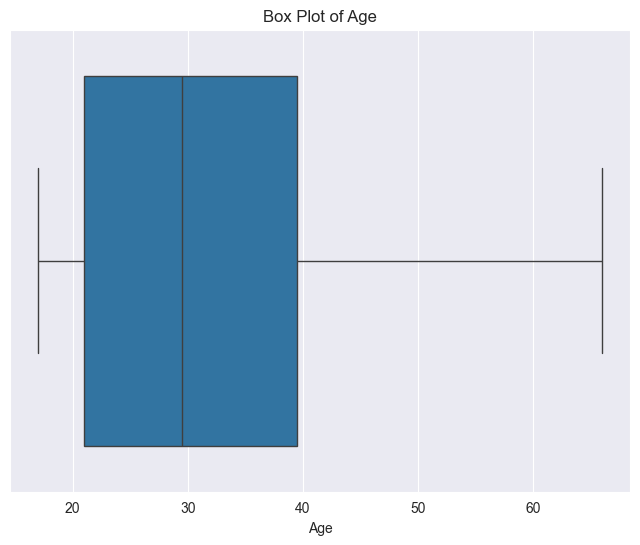

In [49]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['AgeNumeric'])
plt.xlabel('Age')
plt.title('Box Plot of Age')
plt.show()

# Box plot finale